In [2]:
%cd ..

/scratch/big/home/daawic/BSc-Thesis


In [3]:
import os
import torch
import matplotlib.pyplot as plt
from torchvision.transforms import transforms
from project.models import EDMCallum
from project.util.device import get_available_acc
from project.util.plotting import plot_sample
from project.util.data import ReplayMemoryData

In [4]:
PATH = os.path.join("..", "checkpoints", "diff", "BreakoutNoDiff20.pt")
DATA = os.path.join("..", "checkpoints", "memory", "Breakout.pt")

In [5]:
device = "cuda:3"

In [6]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Pad(2),
    transforms.Normalize(0.5, 0.5),
])

In [7]:
data = ReplayMemoryData(
    memory=DATA,
    transform=transform,
    cap=500_000,
    train=False,
)

In [8]:
model = EDMCallum.from_checkpoint(PATH, device, U=3).to(device)

In [14]:
x = torch.zeros((4, 4, 88, 88), device=device)

for i, img in enumerate(torch.randperm(500_000)[:4]):
    x[i] = data[img].to(device)

mask = torch.ones_like(x, device=device)
mask[:, :, :9] = 0
x_masked = x * mask
x_inpainted = model.inpaint(x, mask)

100%|██████████| 32/32 [00:08<00:00,  3.75it/s]


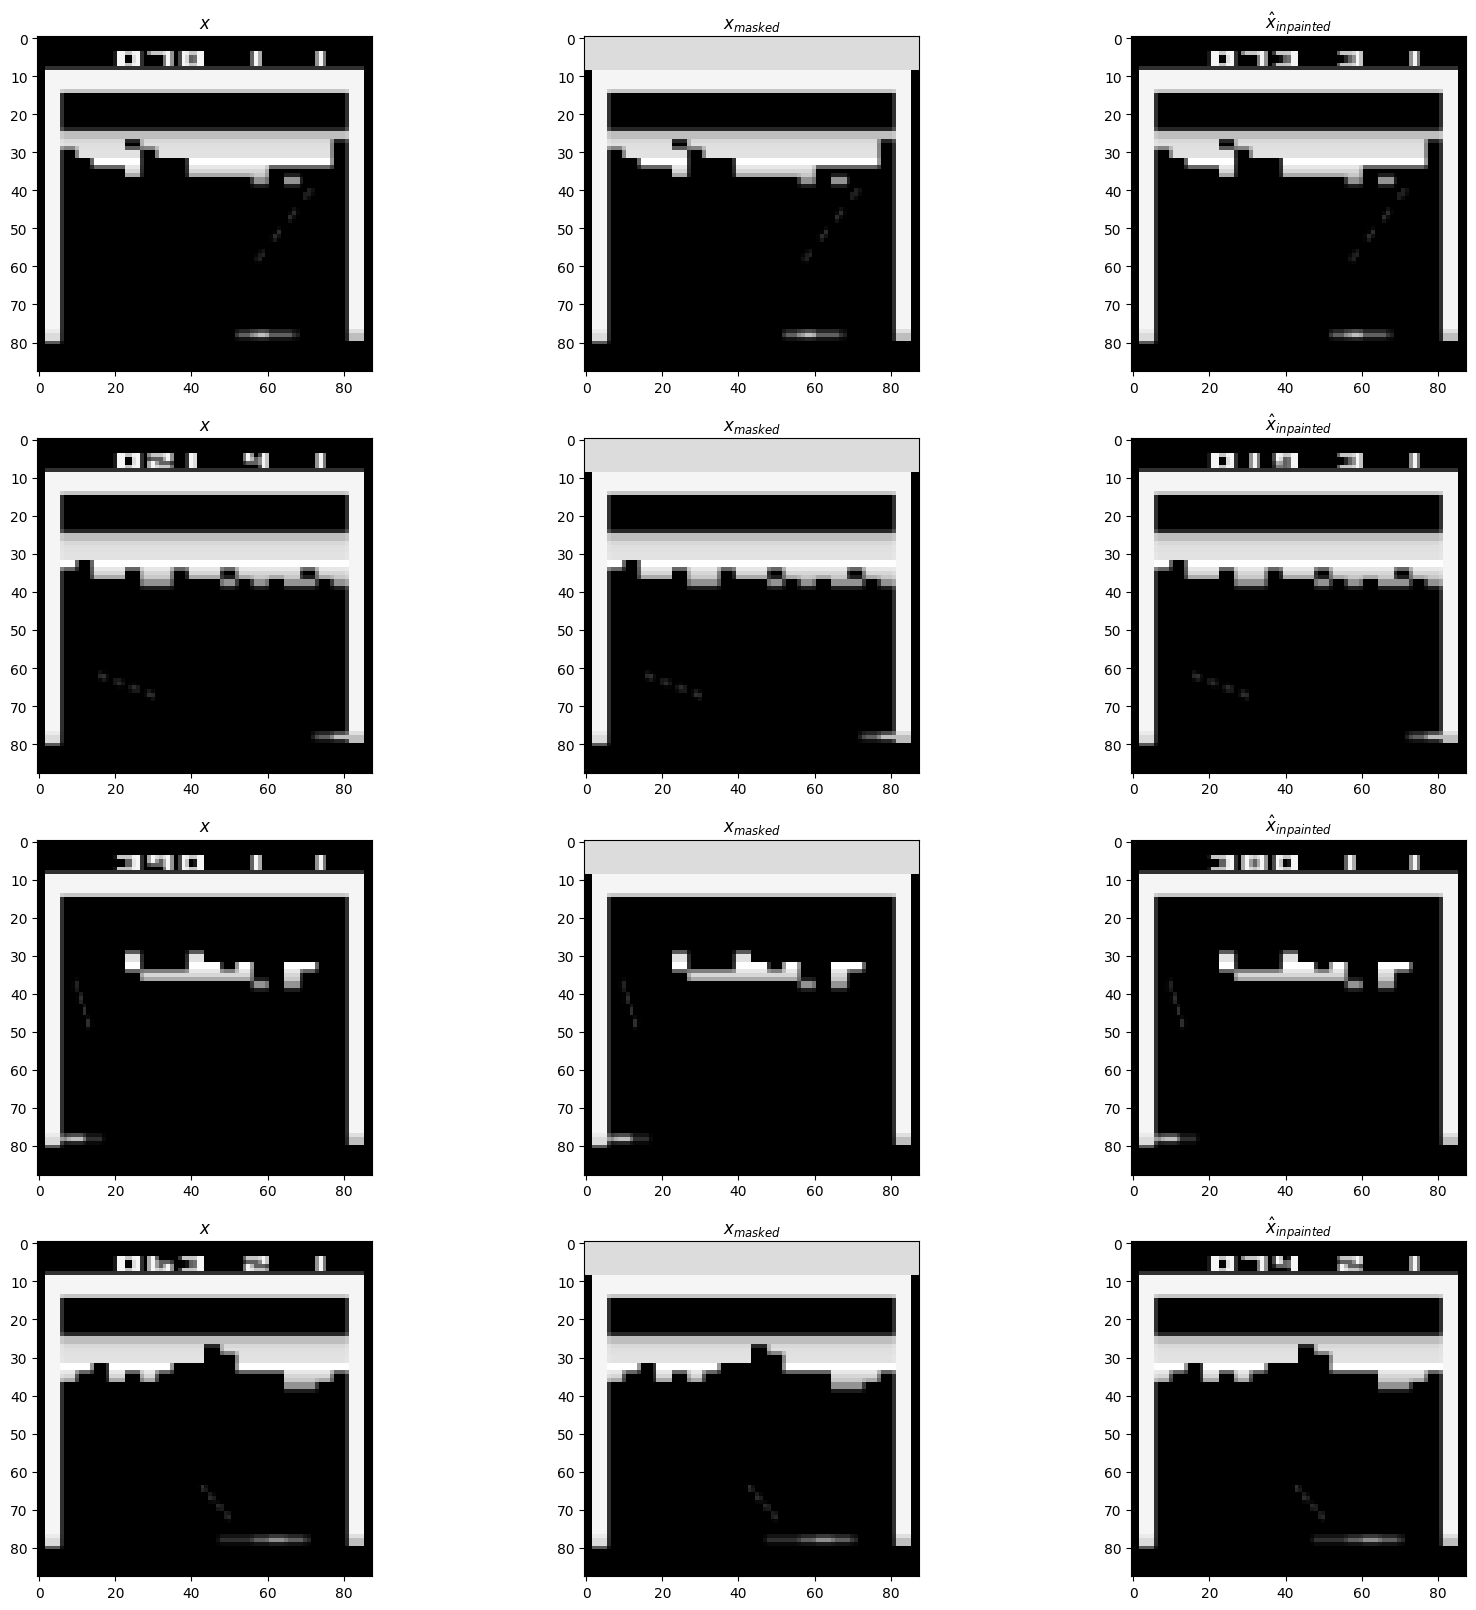

In [15]:
fig, axis = plt.subplots(4, 3, figsize=(20, 20))

for i in range(4):
    axis[i, 0].imshow(x[i].mean(dim=0).to("cpu"), cmap='grey')
    axis[i, 1].imshow(x_masked[i].mean(dim=0).to("cpu"), cmap='grey')
    axis[i, 2].imshow(x_inpainted[i].mean(dim=0).to("cpu"), cmap='grey')
    axis[i, 0].set_title("$x$")
    axis[i, 1].set_title("$x_{masked}$")
    axis[i, 2].set_title("$\\hat{x}_{inpainted}$")

plt.show()